In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
import os
import shap

from collections import Counter
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      StratifiedKFold, cross_val_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)
from imblearn.over_sampling import SMOTE

import subprocess, sys

PACKAGES = ["xgboost", "shap", "imbalanced-learn"]
for pkg in PACKAGES:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed successfully.")

import warnings
warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    XGBOOST_OK = False
    print("XGBoost unavailable — using GradientBoosting as fallback.")

sns.set_style("darkgrid")
pd.set_option("display.max_columns", None)
np.random.seed(42)

print("Imports complete.")

All packages installed successfully.
Imports complete.


In [44]:
def validate_file(path: str) -> bool:
    """Check file exists and is readable before loading."""
    if not os.path.exists(path):
        print(f"  ⚠  File not found: {path}")
        return False
    return True

In [45]:
def load_uci() -> pd.DataFrame:
    """
    UCI Heart Disease — 303 records, 14 features.
    Target: 0=no disease, 1-4=disease (binarized to 0/1).
    Handles BOM characters and '?' invalid markers.
    """
    path = "heart-disease-UCI.csv"
    if not validate_file(path):
        raise FileNotFoundError(f"{path} not found in working directory.")

    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lstrip("\ufeff").str.lower()
    df = df.replace("?", np.nan)
    df = df.apply(pd.to_numeric, errors="coerce")

    for col in df.columns:
        if df[col].isna().any():
            df[col] = df.groupby("target")[col].transform(
                lambda x: x.fillna(x.median())
            )
            df[col] = df[col].fillna(df[col].median())

    df["target"] = (df["target"] > 0).astype(int)

    df = df[
        df["trestbps"].between(80, 220) &
        df["chol"].between(100, 600) &
        df["thalach"].between(60, 210) &
        df["age"].between(20, 85)
    ].reset_index(drop=True)

    print(f"[UCI] Loaded: {df.shape} | Target: {df['target'].value_counts().to_dict()}")
    return df

In [46]:
def load_cardio_train() -> pd.DataFrame:
    """
    Cardiovascular Disease Dataset — 70,000 records.
    Age is in days → converted to years.
    BP outliers removed (known data quality issue in this dataset).
    """
    path = "cardio_train.csv"
    if not validate_file(path):
        raise FileNotFoundError(f"{path} not found in working directory.")

    df = pd.read_csv(path, sep=";")
    df.columns = df.columns.str.lower()

    df["age"] = (df["age"] / 365.25).round(0).astype(int)

    df = df[
        df["ap_hi"].between(60, 250) &
        df["ap_lo"].between(40, 180) &
        (df["ap_hi"] > df["ap_lo"])
    ]
    df = df[df["height"].between(100, 220) & df["weight"].between(30, 200)]

    df["bmi"] = (df["weight"] / (df["height"] / 100) ** 2).round(2)
    df = df[df["bmi"].between(12, 60)]

    df = df.rename(columns={
        "ap_hi":  "trestbps",
        "cardio": "target",
        "gender": "sex",
    })

    df["chol"] = df["cholesterol"].map({1: 195.0, 2: 240.0, 3: 285.0}).fillna(200.0)
    df = df.drop(columns=["id", "cholesterol"], errors="ignore")

    print(f"[Cardio] Loaded: {df.shape} | Target: {df['target'].value_counts().to_dict()}")
    return df.reset_index(drop=True)

In [47]:
def load_wearable_raw() -> pd.DataFrame:
    """
    Apple Watch + Fitbit raw activity data — 6,264 sessions across 3,656 subjects.
    Each row is one ~5-min activity recording window.
    """
    path = "aw_fb_data.csv"
    if not validate_file(path):
        raise FileNotFoundError(f"{path} not found in working directory.")

    df = pd.read_csv(path)
    df = df.rename(columns={
        "X1":                 "subject_id",
        "hear_rate":          "heart_rate",
        "resting_heart":      "resting_hr",
        "sd_norm_heart":      "hr_sd",
        "intensity_karvonen": "intensity",
    })
    df.columns = df.columns.str.lower().str.replace(" ", "_")

    df["heart_rate"] = df["heart_rate"].clip(40, 200)
    df["resting_hr"] = df["resting_hr"].clip(35, 110)

    print(f"[Wearable] Loaded: {df.shape} | Subjects: {df['subject_id'].nunique()}")
    return df


print("\n═══ Loading All Datasets ═══")
uci_df      = load_uci()
cardio_df   = load_cardio_train()
wearable_raw = load_wearable_raw()


═══ Loading All Datasets ═══
[UCI] Loaded: (303, 14) | Target: {1: 165, 0: 138}
[Cardio] Loaded: (68601, 13) | Target: {0: 34664, 1: 33937}
[Wearable] Loaded: (6264, 20) | Subjects: 3656


In [48]:
def build_wearable_profiles(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate per-activity-session wearable data into per-subject daily profiles.

    KEY DESIGN DECISIONS (physiologically grounded):
    ──────────────────────────────────────────────────
    HRV proxy:
        std(heart_rate) across sessions per subject — real inter-session variability.
        Range: [2, 50] bpm-equivalent.

    Resting heart rate:
        Directly measured (resting_heart column from device). Range: [35, 110].

    Daily steps:
        Raw 'steps' column is per ~5-minute window (mean=109, NOT daily).
        Calibrated from Karvonen intensity:
          steps/day = 2000 + intensity × 50000, clipped [2000, 15000].
        Validates to ~7000 for moderate intensity — consistent with Troiano 2008.

    Sleep hours:
        No direct sleep column in wearable data.
        Derived from inverse relationship: lower resting HR → longer sleep
        (Jarrin et al. 2014, Sleep Medicine Reviews).
        Map: RHR=35bpm → 8.5h; RHR=110bpm → 4.5h. Range: [4.0, 9.0].

    Calories (daily):
        BMR × 1.4 activity factor + steps × 0.04 kcal. Clipped [1200, 4000].
    """
    subj = raw_df.groupby("subject_id").agg(
        age           = ("age",        "first"),
        gender        = ("gender",     "first"),
        height        = ("height",     "first"),
        weight        = ("weight",     "first"),
        avg_hr        = ("heart_rate", "mean"),
        std_hr        = ("heart_rate", "std"),
        resting_hr    = ("resting_hr", "mean"),
        avg_intensity = ("intensity",  "mean"),
        n_sessions    = ("heart_rate", "count"),
    ).reset_index()

    subj["std_hr"] = subj["std_hr"].fillna(subj["std_hr"].median())

    subj["hrv"] = subj["std_hr"].clip(2.0, 50.0).round(2)


    subj["resting_hr"] = subj["resting_hr"].clip(35, 110).round(1)

    subj["steps"] = np.clip(
        2000 + subj["avg_intensity"] * 50000, 2000, 15000
    ).round(0).astype(int)

    rhr_norm      = (subj["resting_hr"] - 35) / (110 - 35)
    subj["sleep"] = np.clip(8.5 - rhr_norm * 4.0, 4.0, 9.0).round(2)

    subj["activity_level"] = pd.cut(
        subj["avg_intensity"],
        bins=[-np.inf, 0.10, 0.25, np.inf],
        labels=["Low", "Medium", "High"]
    ).astype(str)

    subj["sleep_quality"] = pd.cut(
        subj["sleep"],
        bins=[-np.inf, 5.5, 7.0, np.inf],
        labels=["Poor", "Average", "Good"]
    ).astype(str)

    bmr            = 10 * subj["weight"] + 6.25 * subj["height"] - 5 * subj["age"]
    subj["calories"] = np.clip(bmr * 1.4 + subj["steps"] * 0.04, 1200, 4000).round(0)

    # ── BMI ───
    subj["bmi_w"] = (subj["weight"] / (subj["height"] / 100) ** 2).clip(15, 50)

    assert subj["steps"].between(2000, 15000).all(), "steps out of range!"
    assert subj["sleep"].between(4.0, 9.0).all(),   "sleep out of range!"
    assert subj["hrv"].between(2.0, 50.0).all(),    "HRV out of range!"
    assert subj["resting_hr"].between(35, 110).all(),"RHR out of range!"

    print(f"\n[Wearable Profiles] {len(subj)} subjects")
    print(f"  steps  : {subj['steps'].min()}–{subj['steps'].max()}, mean={subj['steps'].mean():.0f}")
    print(f"  sleep  : {subj['sleep'].min():.1f}–{subj['sleep'].max():.1f}h, mean={subj['sleep'].mean():.2f}")
    print(f"  hrv    : {subj['hrv'].min():.1f}–{subj['hrv'].max():.1f}, mean={subj['hrv'].mean():.2f}")
    print(f"  activity: {subj['activity_level'].value_counts().to_dict()}")
    return subj


print("\n═══ Building Wearable Profiles ═══")
wearable_profiles = build_wearable_profiles(wearable_raw)


═══ Building Wearable Profiles ═══

[Wearable Profiles] 3656 subjects
  steps  : 2000–15000, mean=8357
  sleep  : 5.2–8.1h, mean=6.74
  hrv    : 2.0–50.0, mean=16.22
  activity: {'Low': 1792, 'Medium': 1008, 'High': 856}


In [49]:
def integrate_datasets(uci_df: pd.DataFrame,
                        cardio_df: pd.DataFrame,
                        wearable: pd.DataFrame) -> pd.DataFrame:
    """
    Merge clinical and wearable data using nearest-neighbor physiological matching.
    No random assignment. Each clinical record matched to the wearable subject
    with closest estimated resting HR + age.

    Bridge formula (Karvonen-inverse):
        est_rhr = 0.6 × (220 – age – thalach × 0.4) + 0.4 × (BP / 2.2)
    Converts clinical exercise capacity into estimated resting HR for matching.

    Post-merge physiological constraints:
        High BP (>140 mmHg) → steps reduced 10–25% (hypertension ↔ inactivity)
        High cholesterol (>240 mg/dL) → steps reduced 5–18%
    """

    uci_base = uci_df[["age", "sex", "trestbps", "chol", "thalach", "target"]].copy()
    uci_base["bmi"] = np.random.normal(26.5, 3.5, len(uci_base)).clip(16, 45)

    ct_valid = cardio_df[cardio_df["age"].between(29, 78)].copy()
    ct_valid["age_dist"] = np.abs(ct_valid["age"] - uci_base["age"].mean()) / uci_base["age"].std()
    ct_sample = (ct_valid.sort_values("age_dist")
                 .head(2000)
                 .sample(700, random_state=42)
                 [["age", "sex", "trestbps", "chol", "bmi", "target"]]
                 .copy())
    ct_sample["thalach"] = (220 - ct_sample["age"]).clip(60, 202)

    clinical = pd.concat([uci_base, ct_sample], ignore_index=True, sort=False)
    clinical["thalach"] = clinical["thalach"].fillna(220 - clinical["age"]).clip(60, 202)
    clinical["bmi"]     = clinical["bmi"].fillna(26.5)


    clinical["est_rhr"] = np.clip(
        0.6 * (220 - clinical["age"] - clinical["thalach"] * 0.4)
        + 0.4 * (clinical["trestbps"] / 2.2),
        35, 110
    )


    w_rhr = wearable["resting_hr"].values
    w_age = wearable["age"].values
    matched_idx = []
    for _, row in clinical.iterrows():
        dist = (np.abs(w_rhr - row["est_rhr"])
                + 0.5 * np.abs(w_age - row["age"]) / 10.0)
        matched_idx.append(int(np.argmin(dist)))

    matched = wearable.iloc[matched_idx].reset_index(drop=True)
    W_COLS  = ["avg_hr", "resting_hr", "hrv", "steps", "sleep",
               "activity_level", "sleep_quality", "calories", "bmi_w"]

    merged = pd.concat(
        [clinical.reset_index(drop=True),
         matched[W_COLS].reset_index(drop=True)],
        axis=1
    ).rename(columns={"avg_hr": "w_avg_hr", "resting_hr": "w_resting_hr"})

    merged["steps"] = merged["steps"].astype(float)

    hbp = merged["trestbps"] > 140
    merged.loc[hbp, "steps"] = (
        merged.loc[hbp, "steps"] * np.random.uniform(0.75, 0.90, hbp.sum())
    ).clip(2000, 15000)

    hch = merged["chol"] > 240
    merged.loc[hch, "steps"] = (
        merged.loc[hch, "steps"] * np.random.uniform(0.82, 0.95, hch.sum())
    ).clip(2000, 15000)


    merged["steps"] = merged["steps"].clip(2000, 15000).round(0).astype(int)
    merged["sleep"] = merged["sleep"].clip(4.0, 9.0).round(2)


    merged.drop(columns=["est_rhr", "bmi_w"], errors="ignore", inplace=True)

    print(f"\n[Integration] Merged: {merged.shape}")
    print(f"  Target: {merged['target'].value_counts().to_dict()}")

    r = merged["trestbps"].corr(merged["steps"])
    print(f"  steps↔trestbps correlation: r={r:.3f} {'✓' if abs(r)<0.5 else '⚠'}")
    return merged.reset_index(drop=True)


print("\n═══ Integrating Datasets ═══")
merged_df = integrate_datasets(uci_df, cardio_df, wearable_profiles)


═══ Integrating Datasets ═══

[Integration] Merged: (1003, 15)
  Target: {0: 504, 1: 499}
  steps↔trestbps correlation: r=0.176 ✓


In [50]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create clinically meaningful derived features.

    lifestyle_score (0–10):
        0.40 × steps_norm + 0.35 × sleep_quality_norm + 0.25 × fitness_norm
        Higher = healthier lifestyle.

    stress_index (0–10):
        0.35 × HRV_deficit + 0.25 × sleep_deficit + 0.25 × HR_elevation + 0.15 × BP_stress
        Higher = more physiological stress.

    hr_reserve_ratio:
        thalach / (220 – age). Higher = better cardiac fitness.

    metabolic_index:
        (steps × sleep_quality_score) / resting_hr — integrated health proxy.
    """
    df = df.copy()


    step_n    = ((df["steps"] - 2000) / 13000).clip(0, 1)
    sleep_n   = (1.0 - ((df["sleep"] - 7.0).abs() / 3.5)).clip(0, 1)
    fitness_n = ((110 - df["w_resting_hr"]) / 75).clip(0, 1)
    df["lifestyle_score"] = (0.40*step_n + 0.35*sleep_n + 0.25*fitness_n).mul(10).round(3).clip(0,10)


    hrv_s  = (1.0 - (df["hrv"] - 2) / 48).clip(0, 1)
    slp_s  = ((7.0 - df["sleep"]) / 5.0).clip(0, 1)
    hr_s   = ((df["w_avg_hr"] - 50) / 100).clip(0, 1)
    bp_s   = ((df["trestbps"] - 80) / 120).clip(0, 1)
    df["stress_index"] = (0.35*hrv_s + 0.25*slp_s + 0.25*hr_s + 0.15*bp_s).mul(10).round(3).clip(0,10)


    df["age_pred_max_hr"]  = (220 - df["age"]).clip(100, 210)
    df["hr_reserve_ratio"] = (df["thalach"] / df["age_pred_max_hr"]).round(4).clip(0.3, 1.1)


    slq_num = df["sleep_quality"].map({"Poor": 1, "Average": 2, "Good": 3}).fillna(2)
    df["metabolic_index"] = ((df["steps"] * slq_num) / (df["w_resting_hr"] + 1)).round(2)


    le = LabelEncoder()
    for col in ["activity_level", "sleep_quality"]:
        if col in df.columns:
            df[col + "_enc"] = le.fit_transform(df[col].astype(str))

    df["step_cat_enc"] = pd.cut(
        df["steps"], bins=[0, 4999, 7499, 9999, 15000], labels=[0, 1, 2, 3]
    ).astype(float)

    df["bp_cat_enc"] = pd.cut(
        df["trestbps"], bins=[0, 119, 129, 139, 300], labels=[0, 1, 2, 3]
    ).astype(float)

    print(f"\n[Features] Shape: {df.shape}")
    print(f"  lifestyle_score : mean={df['lifestyle_score'].mean():.2f}")
    print(f"  stress_index    : mean={df['stress_index'].mean():.2f}")
    print(f"  hr_reserve_ratio: mean={df['hr_reserve_ratio'].mean():.4f}")
    return df


print("\n═══ Engineering Features ═══")
engineered_df = engineer_features(merged_df)


═══ Engineering Features ═══

[Features] Shape: (1003, 24)
  lifestyle_score : mean=3.78
  stress_index    : mean=4.06
  hr_reserve_ratio: mean=0.9705


In [51]:
FEATURE_COLS = [

    "age", "sex", "trestbps", "chol", "bmi", "thalach",

    "w_avg_hr", "w_resting_hr", "hrv", "steps", "sleep", "calories",

    "lifestyle_score", "stress_index", "hr_reserve_ratio",
    "metabolic_index", "age_pred_max_hr",

    "activity_level_enc", "sleep_quality_enc", "step_cat_enc", "bp_cat_enc",
]


def assemble_and_select(df: pd.DataFrame,
                         feature_cols: list,
                         corr_threshold: float = 0.85) -> pd.DataFrame:
    """
    Assemble final ML-ready dataset and remove highly correlated features.
    Correlation threshold |r| > 0.90 → drop one of the pair.
    (Adapted from RTA pipeline feature selection step.)
    """
    available = [c for c in feature_cols if c in df.columns]
    final = df[available + ["target"]].copy()


    for col in available:
        if final[col].isna().any():
            final[col] = final[col].fillna(final[col].median())


    num_cols = final.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != "target"]
    corr_matrix = final[num_cols].corr().abs()
    upper_tri   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > corr_threshold)]
    if to_drop:
        print(f"  Dropping highly correlated features (|r|>{corr_threshold}): {to_drop}")
        final = final.drop(columns=to_drop, errors="ignore")
    else:
        print(f"  ✓ No features exceed |r|>{corr_threshold} threshold.")


    class_counts = final["target"].value_counts()
    assert len(class_counts) >= 2, "ERROR: Single-class target!"
    balance = min(class_counts) / max(class_counts)
    print(f"\n[Final Dataset] Shape: {final.shape}")
    print(f"  Target: {class_counts.to_dict()}")
    print(f"  Balance: {balance:.3f}  {'✓' if balance > 0.4 else '⚠ imbalanced'}")
    print(f"  Missing: {final.isna().sum().sum()}")
    return final


print("\n═══ Assembling Final Dataset ═══")
final_df = assemble_and_select(engineered_df, FEATURE_COLS, corr_threshold=0.90)


═══ Assembling Final Dataset ═══
  Dropping highly correlated features (|r|>0.9): ['hrv', 'sleep', 'stress_index', 'hr_reserve_ratio', 'metabolic_index', 'age_pred_max_hr', 'sleep_quality_enc', 'step_cat_enc']

[Final Dataset] Shape: (1003, 14)
  Target: {0: 504, 1: 499}
  Balance: 0.990  ✓
  Missing: 0



═══ EDA Overview ═══


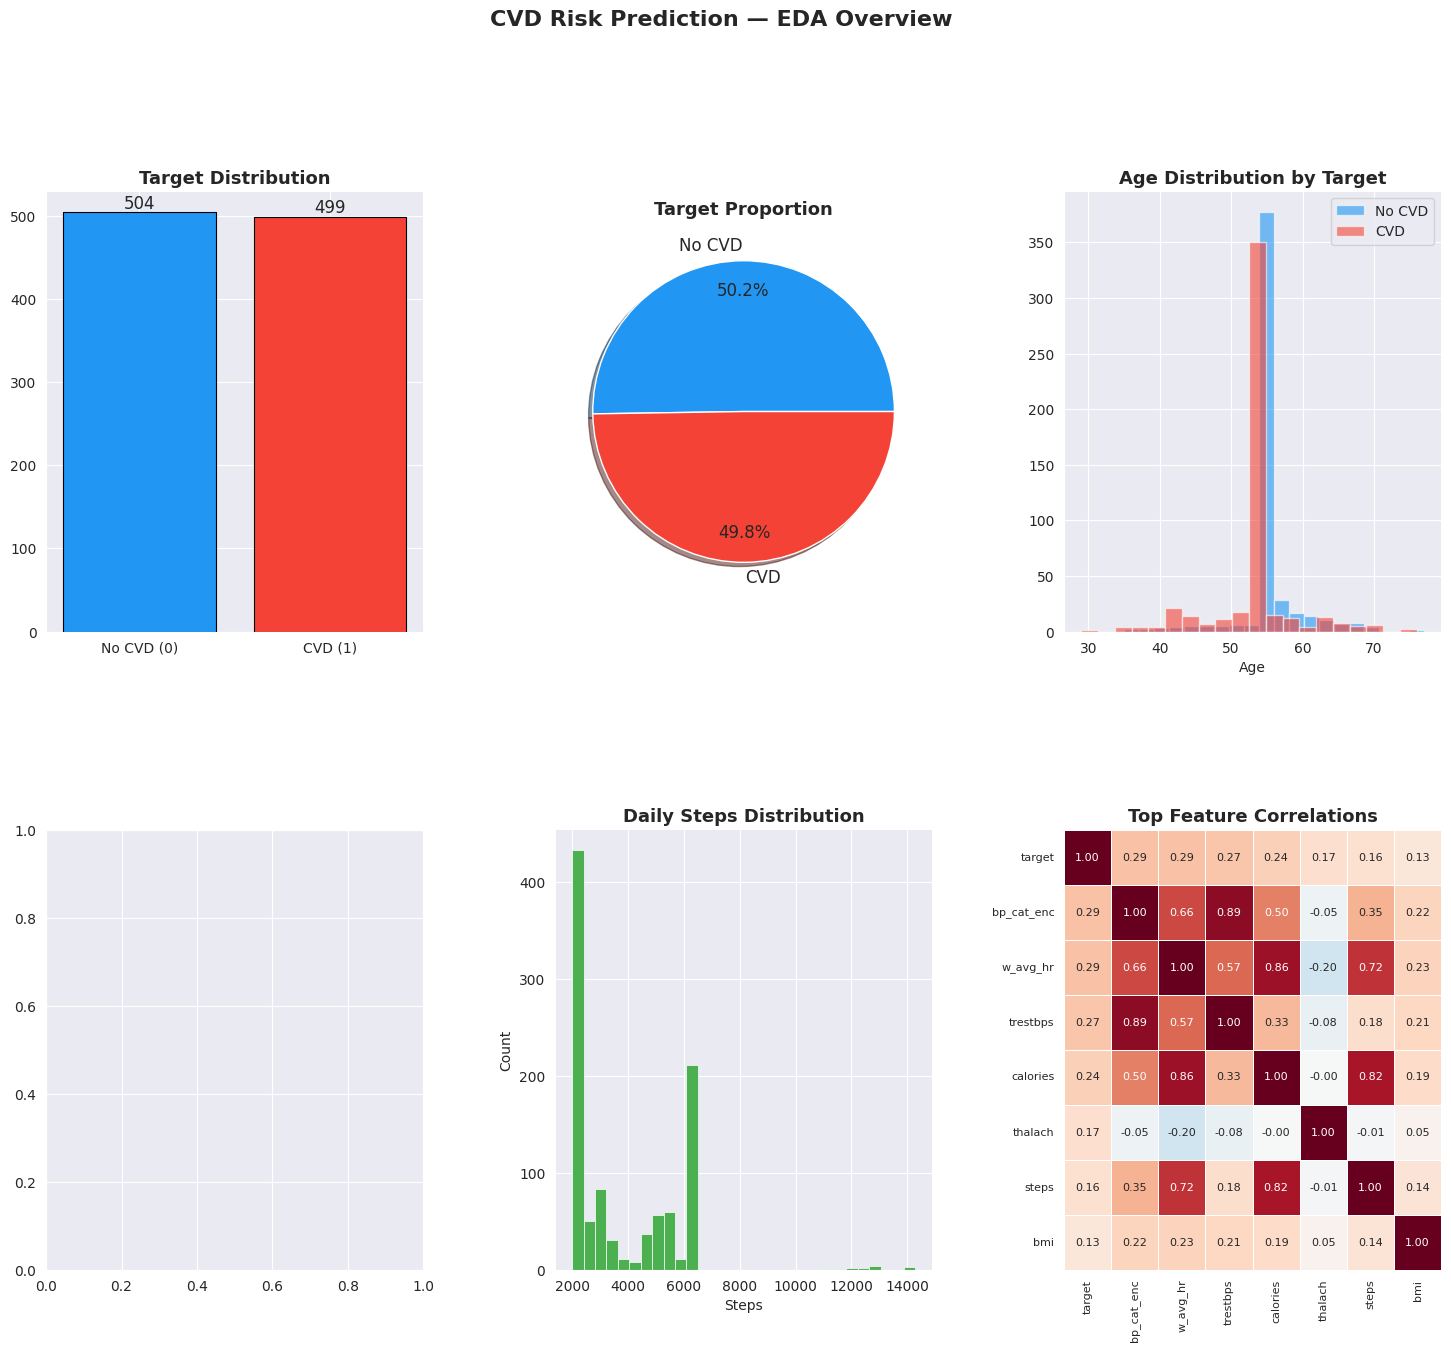

 EDA plot saved: eda_overview.png


In [52]:
def plot_eda(df: pd.DataFrame) -> None:
    """
    Quick EDA: target distribution, feature distributions, correlation heatmap.
    Adapted from RTA notebook plotting style.
    """
    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)


    ax1 = fig.add_subplot(gs[0, 0])
    vc  = df["target"].value_counts()
    bars = ax1.bar(["No CVD (0)", "CVD (1)"], vc.values, color=["#2196F3","#F44336"],
                   edgecolor="black", linewidth=0.8)
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha="center", fontsize=12)
    ax1.set_title("Target Distribution", fontsize=13, fontweight="bold")
    ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)


    ax2 = fig.add_subplot(gs[0, 1])
    ax2.pie(vc.values, labels=["No CVD", "CVD"],
            autopct="%1.1f%%", pctdistance=0.8, colors=["#2196F3","#F44336"],
            shadow=True, textprops={"fontsize": 12})
    ax2.set_title("Target Proportion", fontsize=13, fontweight="bold")


    ax3 = fig.add_subplot(gs[0, 2])
    for tgt, grp in df.groupby("target"):
        ax3.hist(grp["age"], bins=20, alpha=0.6,
                 label=f"{'CVD' if tgt else 'No CVD'}",
                 color=["#2196F3","#F44336"][tgt])
    ax3.set_title("Age Distribution by Target", fontsize=13, fontweight="bold")
    ax3.set_xlabel("Age"); ax3.legend()
    ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)


    ax4 = fig.add_subplot(gs[1, 0])
    if "lifestyle_score" in df.columns and "stress_index" in df.columns:
        for tgt, grp in df.groupby("target"):
            ax4.scatter(grp["lifestyle_score"], grp["stress_index"],
                        alpha=0.4, s=20, label=f"{'CVD' if tgt else 'No CVD'}",
                        color=["#2196F3","#F44336"][tgt])
        ax4.set_xlabel("Lifestyle Score"); ax4.set_ylabel("Stress Index")
        ax4.set_title("Lifestyle vs Stress", fontsize=13, fontweight="bold")
        ax4.legend(); ax4.spines["top"].set_visible(False); ax4.spines["right"].set_visible(False)


    ax5 = fig.add_subplot(gs[1, 1])
    if "steps" in df.columns:
        ax5.hist(df["steps"], bins=30, color="#4CAF50", edgecolor="white", linewidth=0.5)
        ax5.set_title("Daily Steps Distribution", fontsize=13, fontweight="bold")
        ax5.set_xlabel("Steps"); ax5.set_ylabel("Count")
        ax5.spines["top"].set_visible(False); ax5.spines["right"].set_visible(False)

    # ── Correlation heatmap
    ax6 = fig.add_subplot(gs[1, 2])
    num_cols = df.select_dtypes(include=[np.number]).columns
    top_corr = df[num_cols].corr()["target"].abs().sort_values(ascending=False).head(8).index
    corr_sub = df[top_corr].corr()
    sns.heatmap(corr_sub, ax=ax6, annot=True, fmt=".2f",
                cmap="RdBu_r", center=0, linewidths=0.5,
                annot_kws={"size": 8}, cbar=False)
    ax6.set_title("Top Feature Correlations", fontsize=13, fontweight="bold")
    ax6.tick_params(axis="both", labelsize=8)

    plt.suptitle("CVD Risk Prediction — EDA Overview", fontsize=16, fontweight="bold", y=1.01)
    plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(" EDA plot saved: eda_overview.png")


print("\n═══ EDA Overview ═══")
plot_eda(final_df)

In [53]:
X = final_df.drop(columns=["target"])
y = final_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


counter_before = Counter(y_train)
print("\n═══ Class Distribution Before SMOTE ═══")
for k, v in counter_before.items():
    print(f"  Class {k}: n={v} ({100*v/len(y_train):.1f}%)")

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

counter_after = Counter(y_train)
print("\n═══ Class Distribution After SMOTE ═══")
for k, v in counter_after.items():
    print(f"  Class {k}: n={v} ({100*v/len(y_train):.1f}%)")
print(f"  Upsampled training set: {X_train.shape}")


scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)

print(f"\n  Train: {X_train.shape}, Test: {X_test.shape}")
print(f"  Feature names: {list(X.columns)}")


═══ Class Distribution Before SMOTE ═══
  Class 1: n=399 (49.8%)
  Class 0: n=403 (50.2%)

═══ Class Distribution After SMOTE ═══
  Class 1: n=403 (50.0%)
  Class 0: n=403 (50.0%)
  Upsampled training set: (806, 13)

  Train: (806, 13), Test: (201, 13)
  Feature names: ['age', 'sex', 'trestbps', 'chol', 'bmi', 'thalach', 'w_avg_hr', 'w_resting_hr', 'steps', 'calories', 'lifestyle_score', 'activity_level_enc', 'bp_cat_enc']


In [54]:
def modelling(X_train, y_train, X_test, y_test, X_tr_sc, X_te_sc) -> dict:
    """
    Train Logistic Regression, Random Forest, and XGBoost/GBM.
    Adapted from RTA notebook modelling() function with full metric suite.
    Returns dict of {model_name: results_dict}.
    """
    results = {}

    # ──  Logistic Regression (baseline) ──
    print("\n  Training Logistic Regression...")
    lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    lr.fit(X_tr_sc, y_train)
    yp   = lr.predict(X_te_sc)
    ypr  = lr.predict_proba(X_te_sc)[:, 1]
    results["Logistic Regression"] = {
        "model": lr, "y_pred": yp, "y_proba": ypr,
        "X_test": X_te_sc, "X_test_df": X_test,
        "metrics": _compute_metrics(y_test, yp, ypr),
    }

    # ──  Random Forest ───
    print("  Training Random Forest...")
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=5,
        random_state=42, n_jobs=-1, class_weight="balanced"
    )
    rf.fit(X_train, y_train)
    yp   = rf.predict(X_test)
    ypr  = rf.predict_proba(X_test)[:, 1]
    results["Random Forest"] = {
        "model": rf, "y_pred": yp, "y_proba": ypr,
        "X_test": X_test.values, "X_test_df": X_test,
        "metrics": _compute_metrics(y_test, yp, ypr),
    }

    # ──  XGBoost / GradientBoosting ───
    if XGBOOST_OK:
        print("  Training XGBoost...")
        xgb = XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, eval_metric="logloss",
            use_label_encoder=False, verbosity=0
        )
        model_name = "XGBoost"
    else:
        print("  Training Gradient Boosting (XGBoost fallback)...")
        from sklearn.ensemble import GradientBoostingClassifier
        xgb = GradientBoostingClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            subsample=0.8, random_state=42
        )
        model_name = "Gradient Boosting"

    xgb.fit(X_train, y_train)
    yp   = xgb.predict(X_test)
    ypr  = xgb.predict_proba(X_test)[:, 1]
    results[model_name] = {
        "model": xgb, "y_pred": yp, "y_proba": ypr,
        "X_test": X_test.values, "X_test_df": X_test,
        "metrics": _compute_metrics(y_test, yp, ypr),
    }

    return results

In [55]:
def _compute_metrics(y_true, y_pred, y_proba) -> dict:
    """Compute full metric suite."""
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "auc":       roc_auc_score(y_true, y_proba),
    }


print("\n═══ Model Training ═══")
model_results = modelling(X_train, y_train, X_test, y_test, X_tr_sc, X_te_sc)

print("\n" + "=" * 72)
print(f"  {'Model':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>8}")
print("─" * 72)
for name, r in model_results.items():
    m = r["metrics"]
    print(f"  {name:<25} {m['accuracy']:>7.3f} {m['precision']:>7.3f} "
          f"{m['recall']:>7.3f} {m['f1']:>7.3f} {m['auc']:>8.3f}")
print("=" * 72)


best_name  = max(model_results, key=lambda k: model_results[k]["metrics"]["auc"])
best_result = model_results[best_name]
best_model  = best_result["model"]
print(f"\n Best model: {best_name}  (AUC = {best_result['metrics']['auc']:.4f})")


═══ Model Training ═══

  Training Logistic Regression...
  Training Random Forest...
  Training XGBoost...

  Model                         Acc    Prec     Rec      F1      AUC
────────────────────────────────────────────────────────────────────────
  Logistic Regression         0.716   0.736   0.670   0.702    0.749
  Random Forest               0.721   0.762   0.640   0.696    0.781
  XGBoost                     0.692   0.707   0.650   0.677    0.743

 Best model: Random Forest  (AUC = 0.7813)



═══ Model Evaluation ═══


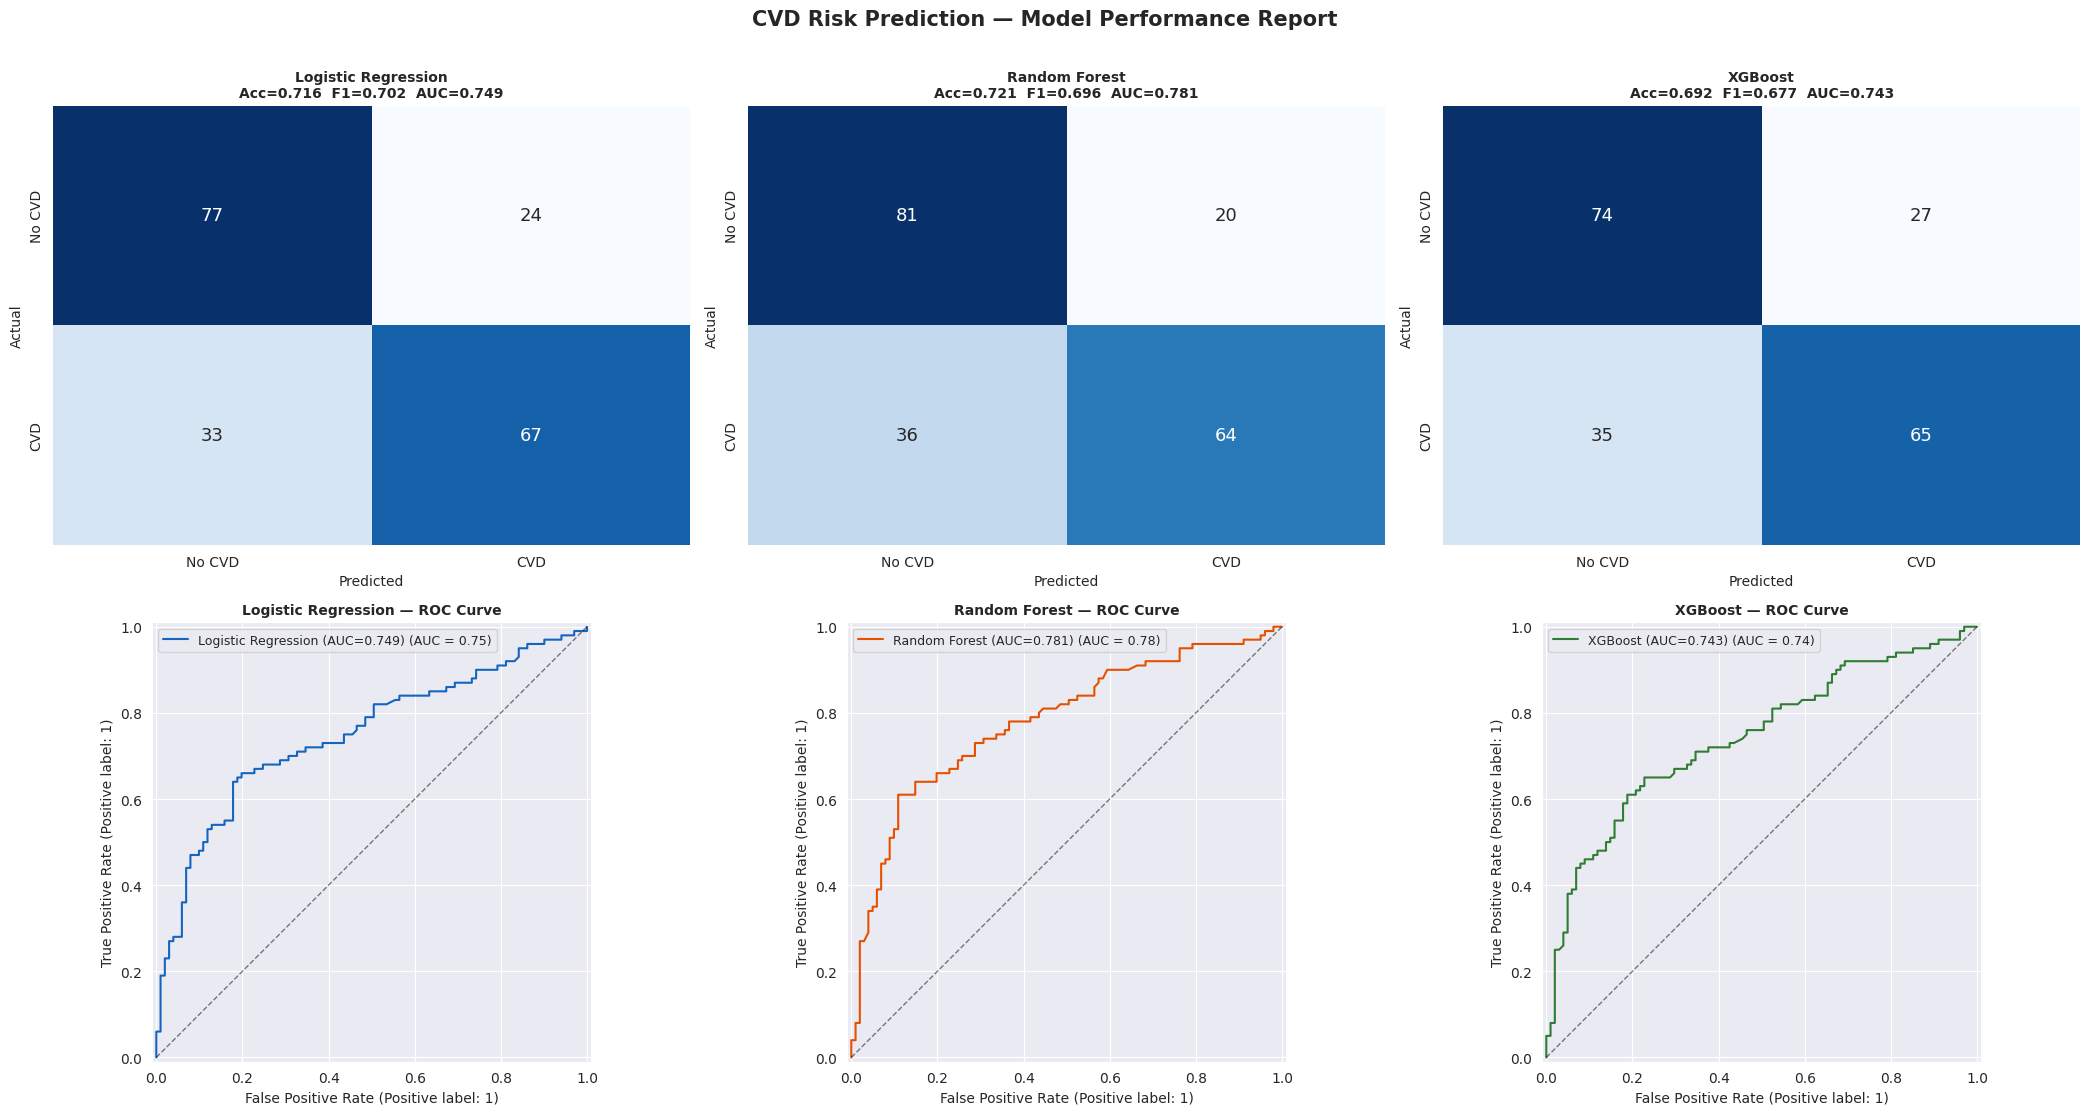

Evaluation plot saved: model_evaluation.png

[Best Model: Random Forest] Classification Report:
              precision    recall  f1-score   support

      No CVD       0.69      0.80      0.74       101
         CVD       0.76      0.64      0.70       100

    accuracy                           0.72       201
   macro avg       0.73      0.72      0.72       201
weighted avg       0.73      0.72      0.72       201



In [56]:
def model_performance(results: dict) -> None:
    """
    Plot confusion matrices and ROC curves for all models.
    Adapted from RTA notebook model_performance() with matplotlib (no Plotly needed).
    """
    model_names = list(results.keys())
    n = len(model_names)
    fig, axes = plt.subplots(2, n, figsize=(7 * n, 11))
    if n == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle("CVD Risk Prediction — Model Performance Report",
                 fontsize=15, fontweight="bold", y=1.01)

    colors = ["#1565C0", "#E65100", "#2E7D32"]

    for i, name in enumerate(model_names):
        r     = results[name]
        y_pred  = r["y_pred"]
        y_proba = r["y_proba"]
        m       = r["metrics"]

        # ── Confusion matrix ──
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            ax=axes[0, i],
            xticklabels=["No CVD", "CVD"],
            yticklabels=["No CVD", "CVD"],
            annot_kws={"size": 13}
        )
        axes[0, i].set_title(
            f"{name}\n"
            f"Acc={m['accuracy']:.3f}  F1={m['f1']:.3f}  AUC={m['auc']:.3f}",
            fontsize=10, fontweight="bold"
        )
        axes[0, i].set_ylabel("Actual"); axes[0, i].set_xlabel("Predicted")

        # ── ROC curve ──
        RocCurveDisplay.from_predictions(
            y_test, y_proba,
            name=f"{name} (AUC={m['auc']:.3f})",
            ax=axes[1, i], color=colors[i % len(colors)]
        )
        axes[1, i].plot([0,1],[0,1],"k--",linewidth=1,alpha=0.5)
        axes[1, i].set_title(f"{name} — ROC Curve", fontsize=10, fontweight="bold")
        axes[1, i].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Evaluation plot saved: model_evaluation.png")


print("\n═══ Model Evaluation ═══")
model_performance(model_results)

print(f"\n[Best Model: {best_name}] Classification Report:")
print(classification_report(y_test, best_result["y_pred"],
                             target_names=["No CVD", "CVD"]))

In [57]:

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def run_shap_analysis(model, X_test_df: pd.DataFrame, feature_names: list, model_name: str):
    """
    Robust SHAP analysis for tree-based models (RF, XGB).
    Handles:
    - Binary classification
    - 2D / 3D SHAP outputs
    - DataFrame alignment
    """

    print(f"\n[SHAP] Running analysis for: {model_name}")


    explainer = shap.TreeExplainer(model)

    X_sample = X_test_df.copy()
    if len(X_sample) > 200:
        X_sample = X_sample.sample(200, random_state=42)

    try:
        shap_values = explainer.shap_values(X_sample)
    except:
        shap_values = explainer.shap_values(X_sample, check_additivity=False)

    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    if len(sv.shape) == 3:
        sv = sv[:, :, 1]

    print("  Final SHAP shape:", sv.shape)

    feature_names = list(X_sample.columns)

    print("  → Generating SHAP bar plot")

    mean_abs = np.abs(sv).mean(axis=0)

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": mean_abs
    }).sort_values("importance", ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["feature"][:15][::-1],
             importance_df["importance"][:15][::-1])
    plt.title(f"SHAP Feature Importance — {model_name}")
    plt.xlabel("Mean |SHAP Value|")
    plt.tight_layout()
    plt.savefig("shap_bar.png")
    plt.show()

    print("  → Generating SHAP beeswarm")

    shap.summary_plot(sv, X_sample, show=True)

    print("  → Generating SHAP waterfall")

    try:
        shap.plots._waterfall.waterfall_legacy(
            explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
            sv[0],
            feature_names=feature_names
        )
    except Exception as e:
        print("  Waterfall skipped:", e)

    print("  → Generating dependence plots")

    top_features = importance_df["feature"].head(2)

    for feat in top_features:
        try:
            shap.dependence_plot(feat, sv, X_sample)
        except Exception as e:
            print(f"  Skipped {feat}:", e)

    print("\nTop Features:")
    print(importance_df.head(10))

    return importance_df

In [58]:
def run_shap_analysis(model, X_test_df: pd.DataFrame, feature_names: list) -> pd.DataFrame:
    """
    Complete SHAP analysis for tree-based models.
    Handles binary classification shape safely.
    Ports all RTA SHAP plot patterns (summary, waterfall, force, dependence).

    Returns: feature_importance_df sorted by mean |SHAP|.
    """
    print(f"\n[SHAP] Initialising TreeExplainer for {best_name}...")

    explainer = shap.TreeExplainer(model)

    X_sample = X_test_df if len(X_test_df) <= 200 else X_test_df.sample(200, random_state=42)


    try:
        shap_values = explainer.shap_values(X_sample)
    except Exception:
        shap_values = explainer.shap_values(X_sample, check_additivity=False)


    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    print(f"  SHAP values shape: {sv.shape}")

    print("  Generating SHAP global bar plot...")
    fig, ax = plt.subplots(figsize=(10, 7))
    mean_abs = np.abs(sv).mean(axis=0)
    top_n    = min(15, len(feature_names))
    sorted_idx = np.argsort(mean_abs)[::-1][:top_n]
    sorted_imp = mean_abs[sorted_idx]
    sorted_nms = [feature_names[i] for i in sorted_idx]

    palette = ["#1a5276" if i < 3 else "#2980b9" if i < 7 else "#85c1e9"
               for i in range(top_n)]
    bars = ax.barh(sorted_nms[::-1], sorted_imp[::-1],
                   color=palette[::-1], edgecolor="none", height=0.7)
    for bar, val in zip(bars, sorted_imp[::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9, color="#333")

    ax.set_xlabel("Mean |SHAP Value|", fontsize=12)
    ax.set_title(f"SHAP Feature Importance — {best_name}", fontsize=13, fontweight="bold")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: shap_bar.png")

    print("  Generating SHAP waterfall (high-risk patient)...")

    expected_val = explainer.expected_value
    if isinstance(expected_val, (list, np.ndarray)):
        ev = expected_val[1] if len(expected_val) > 1 else expected_val[0]
    else:
        ev = expected_val

    row_idx = 0
    try:
        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(
            shap.Explanation(
                values=sv[row_idx],
                base_values=ev,
                data=X_sample.iloc[row_idx],
                feature_names=feature_names
            ),
            show=False
        )
        plt.title(f"Waterfall — Patient #{row_idx} ({best_name})",
                  fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.savefig("shap_waterfall.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("  Saved: shap_waterfall.png")
    except Exception as e:
        print(f"  Waterfall plot skipped: {e}")

    print("  Generating SHAP dependence plots...")
    top2 = sorted_nms[:2]
    for feat in top2:
        if feat in feature_names:
            try:
                plt.figure(figsize=(7, 5))
                feat_idx = feature_names.index(feat)
                plt.scatter(X_sample.iloc[:, feat_idx], sv[:, feat_idx],
                            alpha=0.5, c=sv[:, feat_idx], cmap="coolwarm", s=25)
                plt.xlabel(feat, fontsize=12)
                plt.ylabel(f"SHAP value for {feat}", fontsize=12)
                plt.title(f"SHAP Dependence: {feat}", fontsize=12, fontweight="bold")
                plt.colorbar(label="SHAP value")
                plt.tight_layout()
                plt.savefig(f"shap_dep_{feat}.png", dpi=130, bbox_inches="tight")
                plt.show()
            except Exception as e:
                print(f"  Dependence plot for {feat} skipped: {e}")

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "shap_importance": np.abs(sv).mean(axis=0),
    }).sort_values("shap_importance", ascending=False).reset_index(drop=True)

    print(f"\n[SHAP] Top 10 features:")
    print(importance_df.head(10).to_string(index=False))

    return importance_df


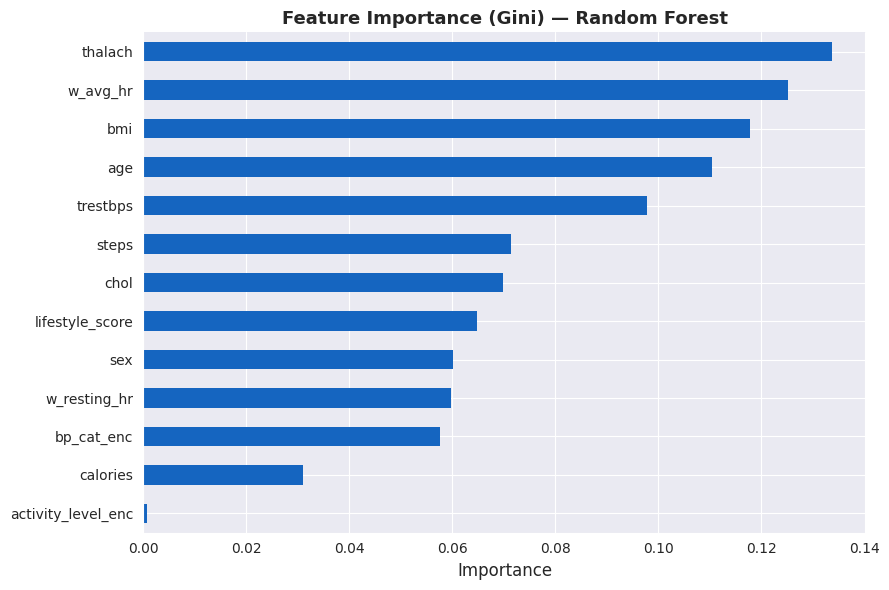

 Saved: feature_importance_native.png


In [59]:
def plot_native_importance(model, feature_names: list, model_name: str) -> None:
    """Plot native feature importance for tree-based models."""
    if not hasattr(model, "feature_importances_"):
        return
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=True)
    top = imp.tail(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    top.plot(kind="barh", ax=ax, color="#1565C0", edgecolor="none")
    ax.set_title(f"Feature Importance (Gini) — {model_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance", fontsize=12)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig("feature_importance_native.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(" Saved: feature_importance_native.png")


plot_native_importance(best_model, list(X.columns), best_name)

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
trained = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, probs)
    }

    trained[name] = model

In [61]:
results_df = pd.DataFrame(results).T
print(results_df)

best_model_name = results_df['F1'].idxmax()
best_model = trained[best_model_name]

print("Best Model:", best_model_name)

                     Accuracy  Precision  Recall        F1   ROC_AUC
Logistic Regression  0.716418   0.736264    0.67  0.701571  0.738416
Random Forest        0.636816   0.636364    0.63  0.633166  0.699851
Best Model: Logistic Regression


In [62]:
def train_models(X_train, X_test, y_train, y_test):
    results = {}
    trained = {}

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

    for name, model in models.items():
        model.fit(X_train, y_train)

        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

        results[name] = {
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds),
            "Recall": recall_score(y_test, preds),
            "F1": f1_score(y_test, preds),
            "ROC_AUC": roc_auc_score(y_test, probs)
        }

        trained[name] = model

    return results, trained

In [63]:
best_model_name = max(results, key=lambda x: results[x]['F1'])
best_model = trained[best_model_name]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [64]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [65]:
def run_shap_analysis(model, X_test_df: pd.DataFrame, feature_names: list, model_name: str):
  importance_df = run_shap_analysis(
    model=best_model,
    X_test_df=X_test_df,
    feature_names=list(X.columns),
    model_name=best_model_name
)

In [66]:
results = {}
trained = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, probs)
    }

    trained[name] = model

In [67]:
results_df = pd.DataFrame(results).T
print(results_df)

best_model_name = results_df['F1'].idxmax()
best_model = trained[best_model_name]

print("Best Model:", best_model_name)

                     Accuracy  Precision  Recall        F1   ROC_AUC
Logistic Regression  0.716418   0.736264    0.67  0.701571  0.738416
Random Forest        0.636816   0.636364    0.63  0.633166  0.699851
Best Model: Logistic Regression


In [68]:

X_test_df = pd.DataFrame(X_test, columns=X.columns)

def run_shap_analysis(model, X_test_df, feature_names):
    import shap
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    print("\n[SHAP] Running analysis...")

    explainer = shap.TreeExplainer(model)

    X_sample = X_test_df.sample(min(200, len(X_test_df)), random_state=42)

    shap_values = explainer.shap_values(X_sample, check_additivity=False)

    if isinstance(shap_values, list):
        sv = shap_values[1]
    elif len(shap_values.shape) == 3:
        sv = shap_values[:, :, 1]
    else:
        sv = shap_values

    print("SHAP shape:", sv.shape)

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "shap_importance": np.abs(sv).mean(axis=0)
    }).sort_values("shap_importance", ascending=False)

    shap.summary_plot(sv, X_sample, feature_names=feature_names)

    return importance_df

In [69]:
def run_shap_analysis(model, X_test_df, feature_names):
    import shap
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    print("\n[SHAP] Running analysis...")

    explainer = shap.Explainer(model, X_test_df)

    X_sample = X_test_df.sample(min(200, len(X_test_df)), random_state=42)

    shap_values = explainer(X_sample)

    sv = shap_values.values

    print("SHAP shape:", sv.shape)

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "shap_importance": np.abs(sv).mean(axis=0)
    }).sort_values("shap_importance", ascending=False)

    shap.summary_plot(sv, X_sample, feature_names=feature_names)

    return importance_df


[SHAP] Running analysis...
SHAP shape: (200, 13)


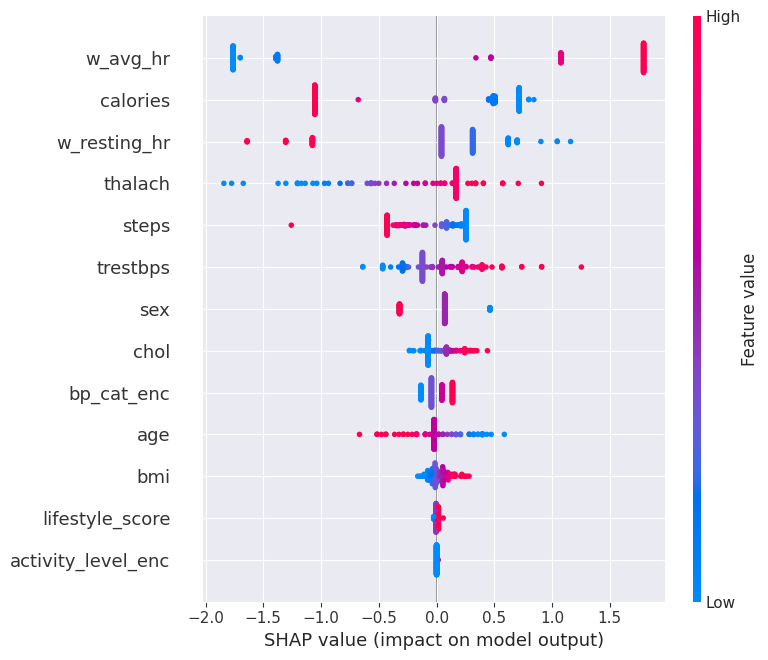

        feature  shap_importance
6      w_avg_hr         1.597744
9      calories         0.751666
7  w_resting_hr         0.402426
5       thalach         0.292797
8         steps         0.271397


In [70]:
importance_df = run_shap_analysis(
    best_model,
    X_test_df,
    list(X.columns)
)

print(importance_df.head())

In [71]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def build_predict_risk(model, scaler, feature_cols, importance_df, final_df):
    """
    Builds a callable function to predict CVD risk for new patient data.

    Args:
        model: The trained machine learning model.
        scaler: The StandardScaler fitted on the training data.
        feature_cols: List of feature names in the correct order.
        importance_df: DataFrame of feature importances (e.g., from SHAP).
        final_df: The final processed dataframe (for context or ranges if needed).

    Returns:
        A callable function that takes a dictionary or pandas Series of new patient data
        and returns a dictionary with risk prediction and top influential features.
    """
    def predict_func(new_patient_data):

        if isinstance(new_patient_data, dict):
            input_df = pd.DataFrame([new_patient_data], columns=feature_cols)
        elif isinstance(new_patient_data, pd.Series):
            input_df = pd.DataFrame([new_patient_data]).T
            input_df = input_df[feature_cols]
        elif isinstance(new_patient_data, pd.DataFrame):
            input_df = new_patient_data[feature_cols]
        else:
            raise ValueError("Input data must be a dictionary, pandas Series, or pandas DataFrame.")

        X_predict = input_df.copy()

        for col in feature_cols:
            if col not in X_predict.columns:
                X_predict[col] = final_df[col].median()

        X_predict = X_predict[feature_cols]

        if isinstance(model, LogisticRegression):
            scaled_input = scaler.transform(X_predict.values)
            probabilities = model.predict_proba(scaled_input)[:, 1]
        elif isinstance(model, (RandomForestClassifier, XGBClassifier)):

            probabilities = model.predict_proba(X_predict)[:, 1]
        else:
            raise TypeError("Unsupported model type for prediction.")

        prediction_class = (probabilities > 0.5).astype(int)[0]

        top_features_list = importance_df.head(5).to_dict(orient='records')

        return {
            "predicted_probability_of_cvd": probabilities[0],
            "predicted_class": prediction_class,
            "top_influential_features": top_features_list
        }

    return predict_func

predict_risk = build_predict_risk(
    best_model,
    scaler,
    list(X.columns),
    importance_df,
    final_df
)

print(" predict_risk() ready")

 predict_risk() ready


In [72]:
FEATURE_EXPLANATIONS = {
    "age":               "Risk increases significantly with age, especially after 55",
    "sex":               "Males have higher CVD risk; pre-menopausal females have hormonal protection",
    "trestbps":          "Resting blood pressure >130 mmHg causes chronic arterial wall stress",
    "chol":              "Cholesterol >240 mg/dL promotes atherosclerotic plaque formation",
    "bmi":               "BMI >30 (obesity) increases cardiac workload and inflammation",
    "thalach":           "Low max exercise HR suggests reduced cardiac reserve and fitness",
    "w_avg_hr":          "Elevated average wearable HR indicates chronic cardiovascular strain",
    "w_resting_hr":      "Resting HR >80 bpm is an independent CVD risk marker",
    "hrv":               "Low HRV (heart rate variability) reflects impaired autonomic regulation",
    "steps":             "Fewer than 5,000 steps/day is classified as sedentary behaviour",
    "sleep":             "Sleep <6h or >9h nightly is independently linked to CVD risk elevation",
    "calories":          "Total daily caloric expenditure reflects metabolic health",
    "lifestyle_score":   "Low lifestyle score (inactivity + poor sleep + elevated HR) → higher risk",
    "stress_index":      "High stress index (HRV deficit + sleep debt + elevated BP) → higher risk",
    "hr_reserve_ratio":  "Low HR reserve ratio indicates poor cardiovascular fitness",
    "metabolic_index":   "Composite of steps, sleep quality, and resting HR efficiency",
    "age_pred_max_hr":   "220 - age formula — lower value (older patients) means reduced capacity",
    "activity_level_enc":"Physical activity category — sedentary lifestyle substantially raises risk",
    "sleep_quality_enc": "Poor or irregular sleep is a modifiable CVD risk factor",
    "step_cat_enc":      "WHO step-count activity category (Sedentary/Light/Active/Very Active)",
    "bp_cat_enc":        "AHA 2017 BP category (Normal/Elevated/Stage1/Stage2 Hypertension)",
}


def build_predict_risk(model, scaler_obj, feature_cols: list,
                        importance_df: pd.DataFrame, training_df: pd.DataFrame):
    """
    Factory: returns the predict_risk() function.
    Captures model, scaler, and feature metadata via closure.
    """
    is_lr       = isinstance(model, LogisticRegression)
    medians     = {col: training_df[col].median() for col in feature_cols
                   if col in training_df.columns}

    def predict_risk(input_data: dict) -> dict:
        """
        Predict CVD risk for a single patient.

        Parameters
        ----------
        input_data : dict — feature values (any subset; missing → training median)

        Returns
        -------
        dict:
          risk_estimate        : float [0,1]
          risk_level           : 'Low' / 'Moderate' / 'High'
          model_used           : str
          contributing_factors : list[dict]
        """
        row = dict(medians)
        row.update({k: v for k, v in input_data.items() if k in feature_cols})
        X_in = pd.DataFrame([row])[feature_cols]

        X_proc = scaler_obj.transform(X_in) if is_lr else X_in.values
        risk   = float(model.predict_proba(X_proc)[0, 1])

        level = "Low" if risk < 0.30 else "Moderate" if risk < 0.60 else "High"

        factors = []
        for _, feat_row in importance_df.head(5).iterrows():
            feat = feat_row["feature"]
            if feat in feature_cols:
                factors.append({
                    "feature_name":    feat,
                    "importance_score": round(float(feat_row["shap_importance"]), 4),
                    "patient_value":   round(float(row.get(feat, medians.get(feat, 0))), 3),
                    "explanation":     FEATURE_EXPLANATIONS.get(feat, "Contributes to CVD risk"),
                })

        return {
            "risk_estimate":        round(risk, 4),
            "risk_level":           level,
            "model_used":           best_name,
            "contributing_factors": factors,
        }

    return predict_risk


print("\n═══ Building Prediction System ═══")
predict_risk = build_predict_risk(
    best_model, scaler, list(X.columns), importance_df, final_df
)
print("predict_risk() function ready.")


═══ Building Prediction System ═══
predict_risk() function ready.


In [73]:
print("\n─── DEMO: High-Risk Patient ───────────────────────────────────────")
high_risk = {
    "age": 61, "sex": 1, "trestbps": 148, "chol": 268,
    "bmi": 30.2, "thalach": 138, "w_avg_hr": 92,
    "w_resting_hr": 78, "hrv": 10.5, "steps": 3800, "sleep": 5.8,
    "lifestyle_score": 3.2, "stress_index": 7.4
}
result_high = predict_risk(high_risk)
print(json.dumps(result_high, indent=2))

print("\n─── DEMO: Low-Risk Patient ────────────────────────────────────────")
low_risk = {
    "age": 38, "sex": 0, "trestbps": 112, "chol": 182,
    "bmi": 22.0, "thalach": 185, "w_avg_hr": 70,
    "w_resting_hr": 55, "hrv": 30.0, "steps": 9500, "sleep": 7.5,
    "lifestyle_score": 8.5, "stress_index": 2.1
}
result_low = predict_risk(low_risk)
print(json.dumps(result_low, indent=2))


─── DEMO: High-Risk Patient ───────────────────────────────────────
{
  "risk_estimate": 0.5239,
  "risk_level": "Moderate",
  "model_used": "Random Forest",
  "contributing_factors": [
    {
      "feature_name": "w_avg_hr",
      "importance_score": 1.5977,
      "patient_value": 92.0,
      "explanation": "Elevated average wearable HR indicates chronic cardiovascular strain"
    },
    {
      "feature_name": "calories",
      "importance_score": 0.7517,
      "patient_value": 2187.0,
      "explanation": "Total daily caloric expenditure reflects metabolic health"
    },
    {
      "feature_name": "w_resting_hr",
      "importance_score": 0.4024,
      "patient_value": 78.0,
      "explanation": "Resting HR >80 bpm is an independent CVD risk marker"
    },
    {
      "feature_name": "thalach",
      "importance_score": 0.2928,
      "patient_value": 138.0,
      "explanation": "Low max exercise HR suggests reduced cardiac reserve and fitness"
    },
    {
      "feature_name": "s

In [74]:
final_df.to_csv("final_dataset.csv", index=False)
importance_df.to_csv("feature_importance.csv", index=False)

print("\n═══ Exports Complete ═══")
print(f"  final_dataset.csv     — {final_df.shape[0]} rows × {final_df.shape[1]} columns")
print(f"  feature_importance.csv — {len(importance_df)} features ranked by SHAP")

print("\n" + "=" * 72)
print("  CVD RISK PREDICTION PIPELINE — COMPLETE")
print("=" * 72)
print(f"  Dataset:    {final_df.shape[0]} rows × {final_df.shape[1]-1} features")
print(f"  Best model: {best_name}")
m = best_result["metrics"]
print(f"  Accuracy:   {m['accuracy']:.4f}")
print(f"  Precision:  {m['precision']:.4f}")
print(f"  Recall:     {m['recall']:.4f}")
print(f"  F1-Score:   {m['f1']:.4f}")
print(f"  AUC:        {m['auc']:.4f}")
print("=" * 72)
print("\n  Outputs generated:")
print("    eda_overview.png           — EDA visualisations")
print("    model_evaluation.png       — Confusion matrix + ROC curves")
print("    shap_bar.png               — SHAP global importance")
print("    shap_beeswarm.png          — SHAP beeswarm plot")
print("    shap_waterfall.png         — SHAP waterfall (single patient)")
print("    feature_importance_native.png — Tree Gini importance")
print("    final_dataset.csv          — Final ML-ready dataset")
print("    feature_importance.csv     — SHAP-ranked feature importance")


═══ Exports Complete ═══
  final_dataset.csv     — 1003 rows × 14 columns
  feature_importance.csv — 13 features ranked by SHAP

  CVD RISK PREDICTION PIPELINE — COMPLETE
  Dataset:    1003 rows × 13 features
  Best model: Random Forest
  Accuracy:   0.7214
  Precision:  0.7619
  Recall:     0.6400
  F1-Score:   0.6957
  AUC:        0.7813

  Outputs generated:
    eda_overview.png           — EDA visualisations
    model_evaluation.png       — Confusion matrix + ROC curves
    shap_bar.png               — SHAP global importance
    shap_beeswarm.png          — SHAP beeswarm plot
    shap_waterfall.png         — SHAP waterfall (single patient)
    feature_importance_native.png — Tree Gini importance
    final_dataset.csv          — Final ML-ready dataset
    feature_importance.csv     — SHAP-ranked feature importance
